Running simulation with 1000 steps and 200 runs...
Plotting results...


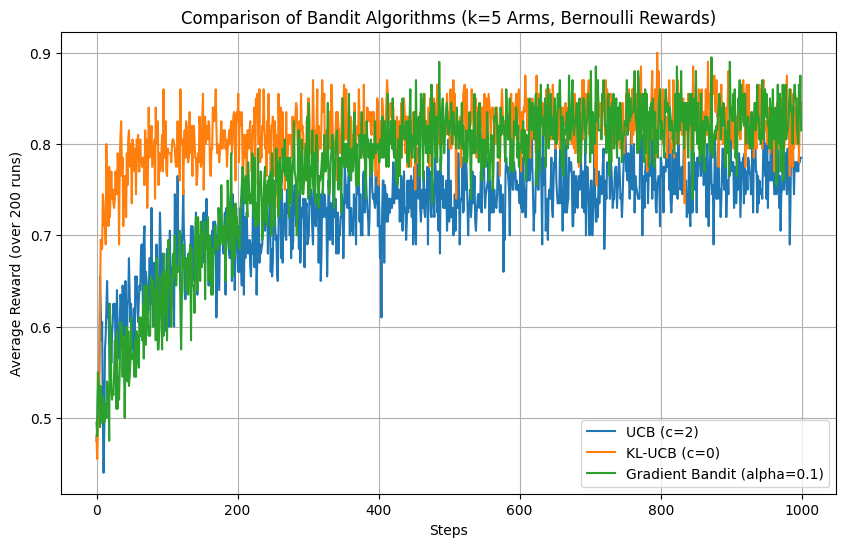

In [ ]:
import numpy as np
import math
from scipy.optimize import bisect
import matplotlib.pyplot as plt

class BanditEnv:
    """Simulates a k-armed bandit environment with Bernoulli rewards."""
    def __init__(self, k=5):
        self.k = k
        # true reward probabilities (0 to 1) for each arm
        # Using a fixed seed for reproducibility across runs is often good practice
        # np.random.seed(42)
        self.q_true = np.random.rand(k)

    def pull(self, action):
        """Simulate pulling an arm and return reward (Bernoulli reward: 0 or 1)."""
        return 1 if np.random.rand() < self.q_true[action] else 0



class UCB:
    """UCB algorithm using Hoeffding's inequality bound."""
    def __init__(self, k, c=2):
        self.k = k
        self.c = c  # exploration parameter
        self.Q = np.zeros(k)  # estimated value
        self.N = np.zeros(k)  # count of pulls

    def select_action(self, t):
        if 0 in self.N:
            return np.argmin(self.N)  # try each action once (optimistic initial)

        # UCB formula: Q(a) + c * sqrt(ln(t) / N(a))
        # t + 1 is used to ensure log(t) is defined for t=0
        ucb_values = self.Q + self.c * np.sqrt(np.log(t + 1) / self.N)
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        # Incremental average update
        self.Q[action] += (reward - self.Q[action]) / self.N[action]



def kl_divergence(p, q):
    """KL-Divergence for Bernoulli distributions."""
    eps = 1e-15
    p, q = np.clip(p, eps, 1 - eps), np.clip(q, eps, 1 - eps)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

class KLUCB:
    """KL-UCB algorithm for Bernoulli rewards."""
    def __init__(self, k, c=0): # c=0 often used for standard KL-UCB
        self.k = k
        self.c = c
        self.Q = np.zeros(k)
        self.N = np.zeros(k)

    def kl_ucb_bound(self, p_hat, n, t):
        """
        Numerically solve for q where n * KL(p_hat || q) <= log(t) + c*log(log(t)).
        Uses the bisection method since the function is monotonic in q.
        """
        if p_hat == 1.0:
            return 1.0

        # The equation to solve for its root (q)
        # f(q) = n * KL(p_hat, q) - (log(t) + c * log(log(t))) = 0
        # t+1 is used for step count, max(1, log(t+1)) handles t=0,1
        term = math.log(t + 1) + self.c * math.log(max(1, math.log(t + 1)))
        f = lambda q: n * kl_divergence(p_hat, q) - term

        # Root must be found between p_hat (lower bound) and 1.0 (upper bound)
        return bisect(lambda q: f(q), p_hat, 1.0, xtol=1e-6)

    def select_action(self, t):
        for a in range(self.k):
            if self.N[a] == 0:
                return a  # ensure all arms tried once

        # Calculate the KL-UCB bound (q) for each arm
        bounds = [self.kl_ucb_bound(self.Q[a], self.N[a], t + 1) for a in range(self.k)]
        return np.argmax(bounds)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]



class GradientBandit:
    """Gradient Bandit algorithm with a baseline."""
    def __init__(self, k, alpha=0.1):
        self.k = k
        self.alpha = alpha  # step size
        self.H = np.zeros(k)  # preferences
        self.avg_reward = 0  # baseline (average reward)
        self.t = 0

    def select_action(self):
        # Softmax distribution for probabilities
        exp_H = np.exp(self.H)
        probs = exp_H / np.sum(exp_H)
        # Select action based on probabilities
        return np.random.choice(self.k, p=probs), probs

    def update(self, action, reward, probs):
        self.t += 1
        # Update baseline (average reward)
        self.avg_reward += (reward - self.avg_reward) / self.t
        baseline = self.avg_reward

        # Gradient Ascent Update Rule
        for a in range(self.k):
            # The (1 - probs[a]) term for the chosen action
            if a == action:
                self.H[a] += self.alpha * (reward - baseline) * (1 - probs[a])
            # The -probs[a] term for the unchosen actions
            else:
                self.H[a] -= self.alpha * (reward - baseline) * probs[a]



def run_experiment(bandit_class, steps=1000, runs=100, k=5):
    """Runs a multi-armed bandit experiment over multiple runs."""
    avg_rewards = np.zeros(steps)

    for _ in range(runs):
        # The environment must be reset for each run
        env = BanditEnv(k)
        agent = bandit_class(k)
        rewards = []
        for t in range(steps):
            if isinstance(agent, GradientBandit):
                action, probs = agent.select_action()
                reward = env.pull(action)
                agent.update(action, reward, probs)
            else:
                # UCB and KLUCB use 't' in their selection logic
                action = agent.select_action(t)
                reward = env.pull(action)
                agent.update(action, reward)
            rewards.append(reward)

        # Accumulate rewards across runs
        avg_rewards += np.array(rewards)

    # Return the average reward per step, averaged over all runs
    return avg_rewards / runs



steps = 1000
runs = 200 # Increasing runs provides a smoother, more reliable average

print(f"Running simulation with {steps} steps and {runs} runs...")

# Run experiments for each algorithm
rewards_ucb = run_experiment(UCB, steps, runs)
rewards_klucb = run_experiment(KLUCB, steps, runs)
rewards_grad = run_experiment(GradientBandit, steps, runs)

print("Plotting results...")

# Plotting
plt.figure(figsize=(10,6))
plt.plot(rewards_ucb, label='UCB (c=2)')
# Note: For KL-UCB, the standard implementation often uses c=0 or c=3
plt.plot(rewards_klucb, label='KL-UCB (c=0)')
plt.plot(rewards_grad, label='Gradient Bandit (alpha=0.1)')
plt.xlabel('Steps')
plt.ylabel(f'Average Reward (over {runs} runs)')
plt.title('Comparison of Bandit Algorithms (k=5 Arms, Bernoulli Rewards)')
plt.legend()
plt.grid(True)
plt.show()